# British Sign Language Fingerspelling Recognition using Bidirectional LSTM

This notebook develops a deep-learning system for recognising British Sign Language (BSL) fingerspelling gestures from video.

MediaPipe Hands is used to extract 3D hand landmarks from video frames. These landmarks are converted into 10-frame temporal sequences and classified using a Bidirectional LSTM neural network.

The notebook covers:
- dataset preprocessing
- hand landmark extraction
- sequence generation
- model training
- model evaluation
- confusion matrix and training curves
- real-time webcam inference

## 1. Project Setup and Dataset Paths

In [5]:
import cv2
import mediapipe as mp
import numpy as np
import os
from pathlib import Path

# Find the main project folder
CURRENT_DIR = Path.cwd()

# If the notebook is running from the notebooks folder,
# move one level up to the main project folder
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

# Project folders
VIDEOS_DIR = PROJECT_ROOT / "data" / "videos"
PROCESS_DIR = PROJECT_ROOT / "data" / "processed_sequences"

SEQUENCE_LENGTH = 10

# Create the processed data folder if it does not exist
PROCESS_DIR.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_ROOT)
print("Videos folder:", VIDEOS_DIR)
print("Processed data folder:", PROCESS_DIR)

Project folder: C:\Users\diyak\Desktop\bsl-fingerspelling-recognition
Videos folder: C:\Users\diyak\Desktop\bsl-fingerspelling-recognition\data\videos
Processed data folder: C:\Users\diyak\Desktop\bsl-fingerspelling-recognition\data\processed_sequences


## 2. Dataset Validation

Before preprocessing, the dataset is checked to confirm that all 26 BSL alphabet folders and their corresponding video files are available.

In [7]:
# Check that Python can find the video dataset

print("Videos folder exists:", VIDEOS_DIR.exists())

# Get all letter folders
letter_folders = sorted(
    [folder.name for folder in VIDEOS_DIR.iterdir() if folder.is_dir()]
)

print("Letter folders found:", letter_folders)
print("Number of letter folders:", len(letter_folders))

# Count MP4 videos
video_files = list(VIDEOS_DIR.rglob("*.mp4"))

print("Number of videos found:", len(video_files))

Videos folder exists: True
Letter folders found: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of letter folders: 26
Number of videos found: 26


## 3. Hand Landmark Extraction

MediaPipe Hands is used to detect up to two hands in each frame. For each hand, 21 landmarks are extracted using x, y and z coordinates.

The landmarks are centred relative to the wrist and represented as 126 features per frame:

2 hands × 21 landmarks × 3 coordinates = 126 features.

In [9]:
# Initialise MediaPipe for hand detection
mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)


# Normalise landmarks using the wrist as the centre
def normalize_landmarks(landmarks):
    # Reshape into:
    # 2 hands, 21 landmarks, 3 coordinates
    landmarks = np.array(landmarks).reshape((2, 21, 3))

    norm_landmarks = []

    for hand in landmarks:
        wrist = hand[0]

        # Centre all landmarks around the wrist
        hand = hand - wrist

        norm_landmarks.append(hand)

    # Convert everything back into one list of 126 values
    return np.array(norm_landmarks).flatten().tolist()


# Extract 3D landmarks for left and right hands
def extract_landmarks_from_frame(results):

    # Create empty placeholders for both hands
    left_hand = [0.0] * 63
    right_hand = [0.0] * 63

    # If no hands are detected, return 126 zeros
    if not results.multi_hand_landmarks:
        return [0.0] * 126

    # Go through each detected hand
    for hand_landmarks, handedness in zip(
        results.multi_hand_landmarks,
        results.multi_handedness
    ):

        coords = []

        # Extract x, y and z for all 21 landmarks
        for lm in hand_landmarks.landmark:
            coords.extend([lm.x, lm.y, lm.z])

        # Find whether MediaPipe detected a left or right hand
        hand_label = handedness.classification[0].label

        if hand_label == "Left":
            left_hand = coords

        elif hand_label == "Right":
            right_hand = coords

    # Always keep the same order:
    # Left hand first, right hand second
    landmarks = left_hand + right_hand

    # Make sure we have exactly 126 values
    if len(landmarks) != 126:
        return [0.0] * 126

    return normalize_landmarks(landmarks)

## 4. Video Preprocessing and Sequence Generation

Each video is converted into overlapping sequences of 10 consecutive frames. Each sequence therefore has a shape of `(10, 126)` and is saved as a NumPy array for model training.

In [11]:
# Process videos and create 10-frame sequences
def process_videos(labels_to_process=None):

    # Get all letter folders inside the videos folder
    labels = sorted([
        folder.name
        for folder in VIDEOS_DIR.iterdir()
        if folder.is_dir()
    ])

    # Only process selected letters if specified
    if labels_to_process is not None:
        labels = [
            label for label in labels
            if label in labels_to_process
        ]

    for label in labels:

        label_dir = VIDEOS_DIR / label
        save_dir = PROCESS_DIR / label

        # Create folder for processed sequences
        save_dir.mkdir(parents=True, exist_ok=True)

        print(f"\nProcessing letter: {label}")

        for video_file in label_dir.iterdir():

            # Ignore anything that is not an MP4 video
            if video_file.suffix.lower() != ".mp4":
                continue

            print(f"Processing video: {video_file.name}")

            cap = cv2.VideoCapture(str(video_file))

            sequence = []

            while True:
                ret, frame = cap.read()

                if not ret:
                    break

                # Flip frame horizontally
                frame = cv2.flip(frame, 1)

                # Convert BGR image to RGB for MediaPipe
                rgb = cv2.cvtColor(
                    frame,
                    cv2.COLOR_BGR2RGB
                )

                # Detect hands
                results = hands.process(rgb)

                # Extract 126 landmark values
                landmarks = extract_landmarks_from_frame(results)

                sequence.append(landmarks)

            cap.release()

            saved_count = 0

            # Break the video into overlapping 10-frame sequences
            if len(sequence) >= SEQUENCE_LENGTH:

                for i in range(
                    len(sequence) - SEQUENCE_LENGTH + 1
                ):

                    chunk = sequence[
                        i:i + SEQUENCE_LENGTH
                    ]

                    chunk_array = np.array(chunk)

                    # Only save sequences with the correct shape
                    if chunk_array.shape == (
                        SEQUENCE_LENGTH,
                        126
                    ):

                        save_path = (
                            save_dir /
                            f"{video_file.stem}_{i}.npy"
                        )

                        np.save(
                            save_path,
                            chunk_array
                        )

                        saved_count += 1

            print(
                f"Saved {saved_count} sequences "
                f"for letter {label}"
            )

## 5. Dataset Quality Checks

The processed dataset is checked to ensure that every sequence has the expected `(10, 126)` shape and contains no missing values.

In [ ]:
# Check the number of processed sequences for each letter

for label in sorted([
    folder.name
    for folder in PROCESS_DIR.iterdir()
    if folder.is_dir()
]):
    files = list((PROCESS_DIR / label).glob("*.npy"))

    print(
        f"Letter {label}: {len(files)} sequences"
    )

In [21]:
# Check that all processed files have the correct shape
# and contain no missing values

wrong_shape = []
missing_values = []
total_files = 0

for label_folder in PROCESS_DIR.iterdir():

    if not label_folder.is_dir():
        continue

    for file in label_folder.glob("*.npy"):

        data = np.load(file)
        total_files += 1

        # Every sequence should contain 10 frames and 126 features
        if data.shape != (10, 126):
            wrong_shape.append(str(file))

        # Check for NaN values
        if np.isnan(data).any():
            missing_values.append(str(file))


print("Total processed sequences:", total_files)
print("Files with wrong shape:", len(wrong_shape))
print("Files with missing values:", len(missing_values))

Total processed sequences: 10569
Files with wrong shape: 0
Files with missing values: 0


## 6. Model Training

The processed sequences are divided into training, validation and test sets.

A Bidirectional LSTM is used to learn temporal patterns across consecutive hand-landmark frames.

In [23]:
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import LearningRateScheduler, ModelCheckpoint
from tensorflow.keras.optimizers import Adam


# -------------------------
# CONFIGURATION
# -------------------------

# Folder containing the processed .npy sequences
SEQUENCE_DIR = PROJECT_ROOT / "data" / "processed_sequences"

# Folder where models will be saved
MODEL_DIR = PROJECT_ROOT / "models"

# Create the models folder if it does not exist
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Model settings
SEQUENCE_LENGTH = 10
NUM_FEATURES = 126
EPOCHS = 30
BATCH_SIZE = 32
INITIAL_LR = 0.001


# -------------------------
# LOAD THE DATA
# -------------------------

sequences = []
labels = []

# Go through every A-Z folder
for label_dir in sorted(SEQUENCE_DIR.iterdir()):

    if not label_dir.is_dir():
        continue

    label = label_dir.name

    # Load every .npy sequence inside the letter folder
    for file in label_dir.glob("*.npy"):

        sequence = np.load(file)

        # Only use files with the correct shape
        if sequence.shape == (SEQUENCE_LENGTH, NUM_FEATURES):
            sequences.append(sequence)
            labels.append(label)


# Convert lists into NumPy arrays
sequences = np.array(sequences)
labels = np.array(labels)

print("Total sequences:", len(sequences))
print("Sequence shape:", sequences.shape)
print("Number of labels:", len(labels))


# -------------------------
# ENCODE THE A-Z LABELS
# -------------------------

le = LabelEncoder()

# Convert A-Z into numbers 0-25
labels_encoded = le.fit_transform(labels)

# Convert the numbers into one-hot encoded labels
labels_categorical = to_categorical(labels_encoded)

print("Classes:", le.classes_)
print("Number of classes:", len(le.classes_))


# -------------------------
# SPLIT THE DATA
# -------------------------

# First split:
# 80% for training
# 20% temporarily for validation + testing
X_train, X_temp, y_train, y_temp, labels_train, labels_temp = train_test_split(
    sequences,
    labels_categorical,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=42
)

# Split the remaining 20% equally:
# 10% validation
# 10% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=labels_temp,
    random_state=42
)

print("\nDataset split:")
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)


# -------------------------
# LEARNING RATE
# -------------------------

# Reduce the learning rate by 10% after every epoch
def lr_schedule(epoch):
    return INITIAL_LR * (0.9 ** epoch)


lr_scheduler = LearningRateScheduler(lr_schedule)


# -------------------------
# BUILD THE BILSTM MODEL
# -------------------------

model = Sequential([
    Input(shape=(SEQUENCE_LENGTH, NUM_FEATURES)),

    Bidirectional(
        LSTM(
            128,
            return_sequences=True,
            activation="relu"
        )
    ),


    Dropout(0.4),

    Bidirectional(
        LSTM(
            64,
            activation="relu"
        )
    ),

    Dropout(0.3),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        len(le.classes_),
        activation="softmax"
    )
])


# Use Adam optimizer
optimizer = Adam(
    learning_rate=INITIAL_LR
)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# -------------------------
# SAVE THE BEST MODEL
# -------------------------

best_model_path = MODEL_DIR / "bsl_lstm_best_model.h5"

checkpoint = ModelCheckpoint(
    filepath=str(best_model_path),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)


# -------------------------
# TRAIN THE MODEL
# -------------------------

history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    callbacks=[
        lr_scheduler,
        checkpoint
    ]
)


# -------------------------
# SAVE THE FINAL MODEL
# -------------------------

final_model_path = MODEL_DIR / "final_bsl_lstm_model.h5"

model.save(
    str(final_model_path)
)


# -------------------------
# SAVE THE LABEL ENCODER
# -------------------------

encoder_path = MODEL_DIR / "label_encoder.pkl"

with open(encoder_path, "wb") as f:
    pickle.dump(le, f)


print("\nModel training complete.")
print("Best model saved to:", best_model_path)
print("Final model saved to:", final_model_path)
print("Label encoder saved to:", encoder_path)

Total sequences: 10569
Sequence shape: (10569, 10, 126)
Number of labels: 10569
Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Number of classes: 26

Dataset split:
Training: (8455, 10, 126)
Validation: (1057, 10, 126)
Testing: (1057, 10, 126)


C:\Users\diyak\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 10, 256)        │       261,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,418 (1.66 MB)

...

265/265 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.8469 - loss: 0.5093 - val_accuracy: 0.8439 - val_loss: 0.5327 - learning_rate: 9.8477e-05
Epoch 24/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8466 - loss: 0.5059
Epoch 24: val_accuracy did not improve from 0.84390
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8466 - loss: 0.5059 - val_accuracy: 0.8439 - val_loss: 0.5342 - learning_rate: 8.8629e-05
Epoch 25/30
263/265 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8463 - loss: 0.5053
Epoch 25: val_accuracy improved from 0.84390 to 0.84484, saving model to C:\Users\diyak\Desktop\bsl-fingerspelling-recognition\models\bsl_lstm_best_model.h5


265/265 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.8463 - loss: 0.5053 - val_accuracy: 0.8448 - val_loss: 0.5293 - learning_rate: 7.9766e-05
Epoch 26/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8506 - loss: 0.4994
Epoch 26: val_accuracy did not improve from 0.84484
265/265 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.8506 - loss: 0.4994 - val_accuracy: 0.8401 - val_loss: 0.5295 - learning_rate: 7.1790e-05
Epoch 27/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8501 - loss: 0.4969
Epoch 27: val_accuracy did not improve from 0.84484
265/265 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.8501 - loss: 0.4969 - val_accuracy: 0.8448 - val_loss: 0.5292 - learning_rate: 6.4611e-05
Epoch 28/30
264/265 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8525 - loss: 0.4945
Epoch 28: val_accuracy improved from 0.84484 to 0.84579, saving model to C:\Users\diyak\Desktop\bsl-fingerspelling-recognition\models\bsl_lstm_best_model.h5


265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.8525 - loss: 0.4945 - val_accuracy: 0.8458 - val_loss: 0.5285 - learning_rate: 5.8150e-05
Epoch 29/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8492 - loss: 0.5098
Epoch 29: val_accuracy improved from 0.84579 to 0.84674, saving model to C:\Users\diyak\Desktop\bsl-fingerspelling-recognition\models\bsl_lstm_best_model.h5


265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8492 - loss: 0.5098 - val_accuracy: 0.8467 - val_loss: 0.5279 - learning_rate: 5.2335e-05
Epoch 30/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8489 - loss: 0.5020
Epoch 30: val_accuracy did not improve from 0.84674
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.8489 - loss: 0.5020 - val_accuracy: 0.8448 - val_loss: 0.5265 - learning_rate: 4.7101e-05



Model training complete.
Best model saved to: C:\Users\diyak\Desktop\bsl-fingerspelling-recognition\models\bsl_lstm_best_model.h5
Final model saved to: C:\Users\diyak\Desktop\bsl-fingerspelling-recognition\models\final_bsl_lstm_model.h5
Label encoder saved to: C:\Users\diyak\Desktop\bsl-fingerspelling-recognition\models\label_encoder.pkl


In [25]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Load the model that achieved the best validation accuracy
best_model = tf.keras.models.load_model(
    MODEL_DIR / "bsl_lstm_best_model.h5"
)

# Evaluate the model on the test dataset
test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nTest results:")
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8451 - loss: 0.5153

Test results:
Test loss: 0.5039951801300049
Test accuracy: 0.8476821184158325


## 7. Model Evaluation

The best model checkpoint is evaluated on the held-out test dataset. Performance is assessed using accuracy, precision, recall and F1-score.

In [27]:
# Make predictions on the test dataset
y_pred = best_model.predict(
    X_test,
    verbose=0
)

# Convert predicted probabilities into class numbers
y_pred_labels = np.argmax(
    y_pred,
    axis=1
)

# Convert the true one-hot labels into class numbers
y_true_labels = np.argmax(
    y_test,
    axis=1
)

print("Predictions created successfully.")

Predictions created successfully.


In [29]:
# Show precision, recall and F1-score for each BSL letter

print("Classification Report:\n")

print(
    classification_report(
        y_true_labels,
        y_pred_labels,
        target_names=le.classes_
    )
)

Classification Report:

              precision    recall  f1-score   support

           A       1.00      0.88      0.94        41
           B       1.00      0.85      0.92        41
           C       1.00      0.91      0.95        34
           D       0.97      0.81      0.89        43
           E       1.00      1.00      1.00        21
           F       0.97      0.79      0.87        39
           G       1.00      0.69      0.81        32
           H       1.00      0.86      0.93        43
           I       0.97      0.89      0.93        35
           J       0.98      0.86      0.92        59
           K       1.00      0.83      0.91        36
           L       0.91      0.75      0.82        40
           M       0.95      0.83      0.89        42
           N       0.94      0.77      0.85        44
           O       1.00      0.88      0.94        42
           P       0.28      1.00      0.43        53
           Q       0.97      0.87      0.92        39
   

## 8. Confusion Matrix

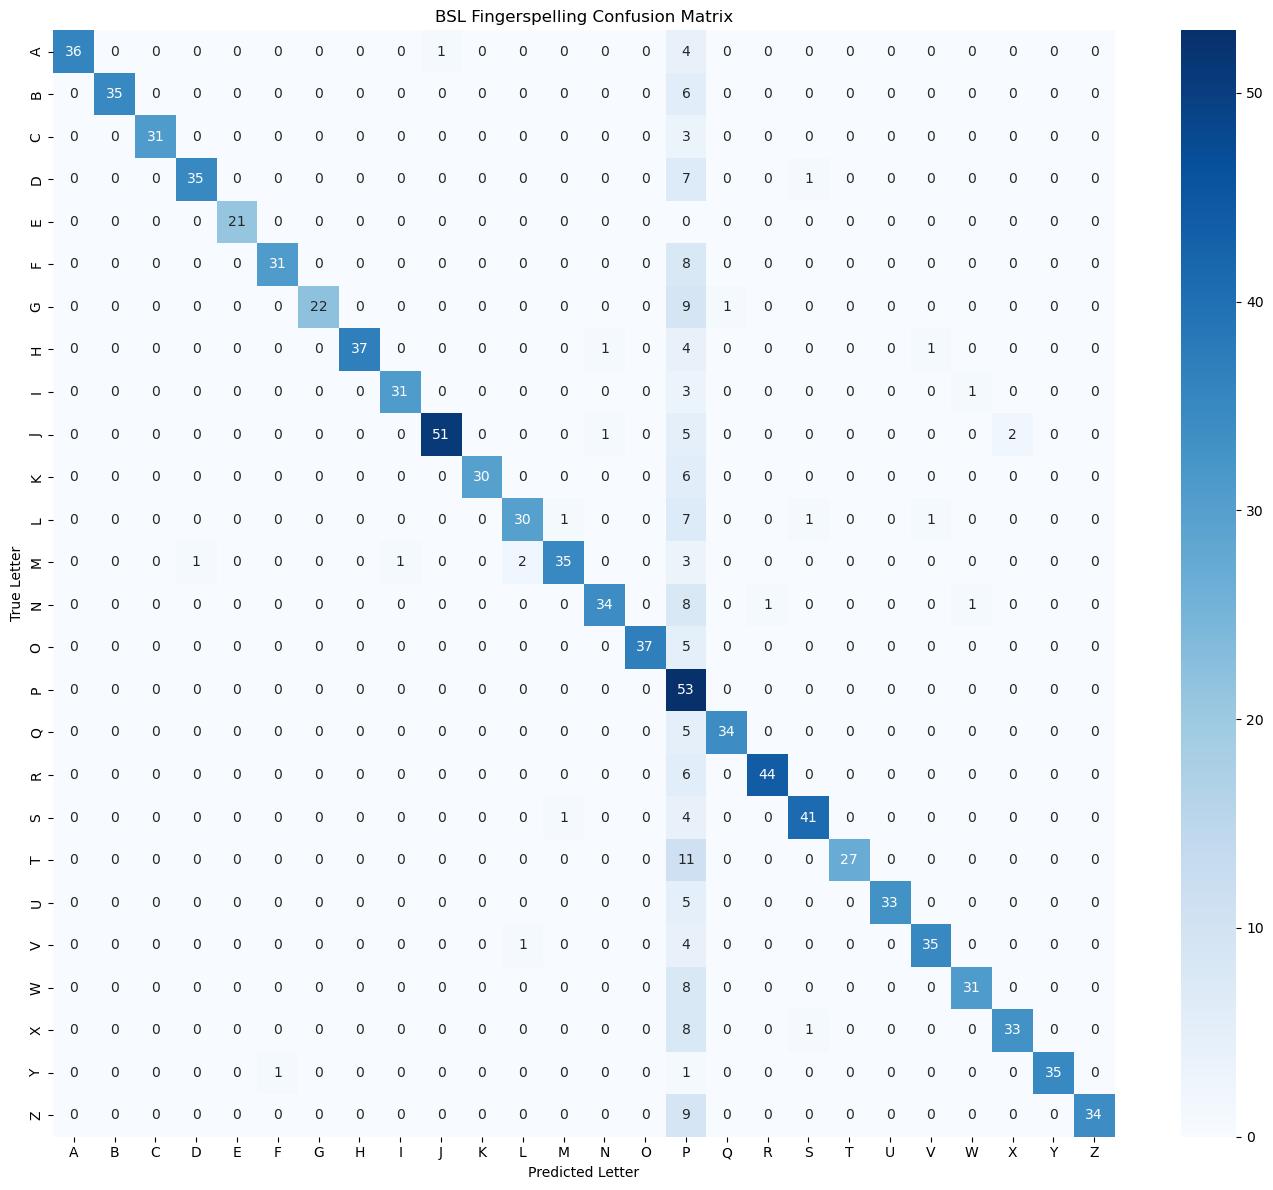

<Figure size 640x480 with 0 Axes>

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the confusion matrix
cm = confusion_matrix(
    y_true_labels,
    y_pred_labels
)

# Create the figure
plt.figure(figsize=(14, 12))

# Plot the confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)




## 9. Training Performance

Training and validation loss and accuracy are visualised across the 30 training epochs.

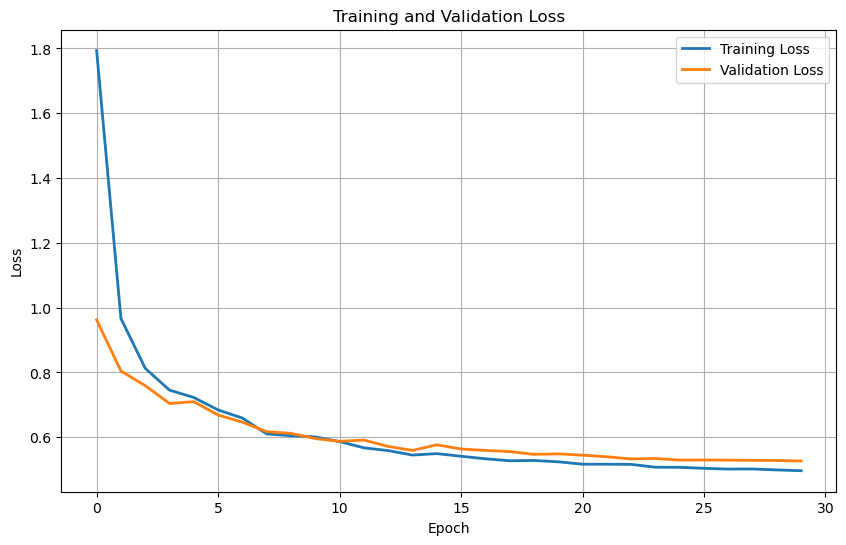

In [35]:
import matplotlib.pyplot as plt

# Create results folder if it does not already exist
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Plot training and validation loss
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

# Save the graph
plt.savefig(
    RESULTS_DIR / "training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

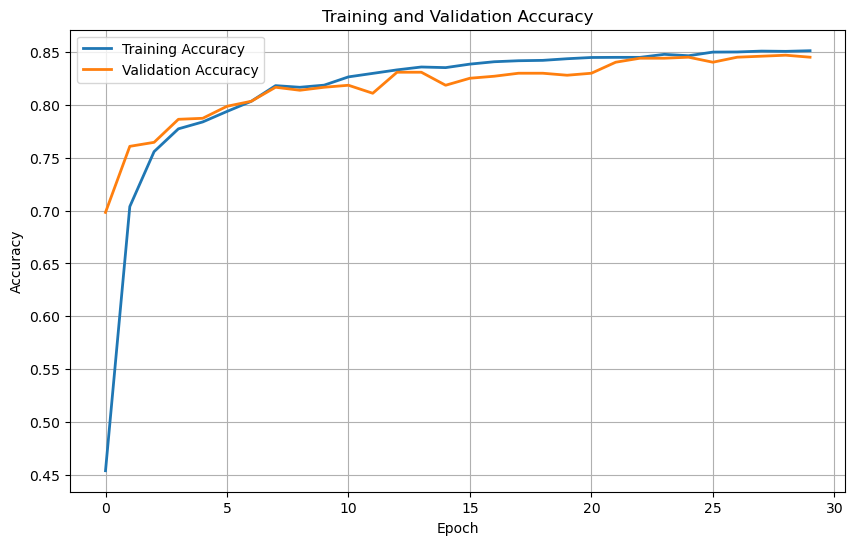

In [37]:
# Plot training and validation accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

# Save the graph
plt.savefig(
    RESULTS_DIR / "training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

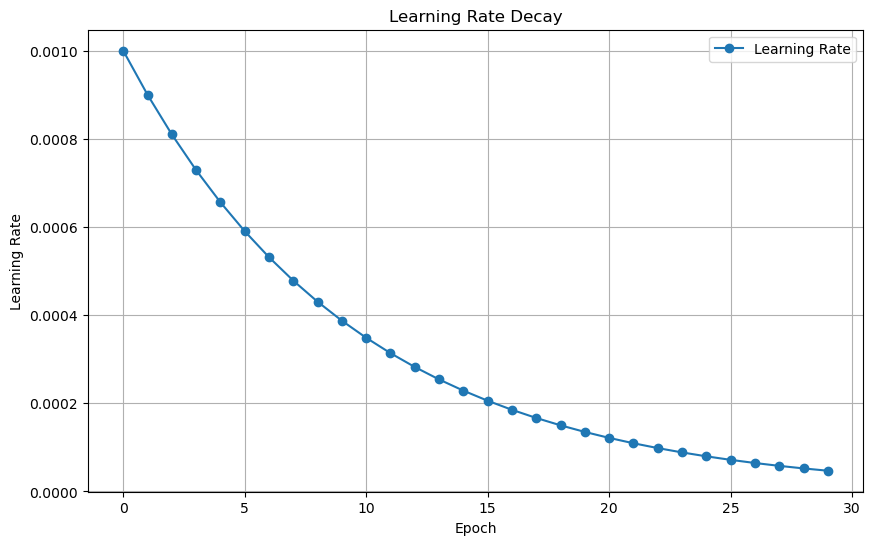

In [39]:
# Calculate the learning rate used for every epoch
learning_rates = [
    INITIAL_LR * (0.9 ** epoch)
    for epoch in range(EPOCHS)
]

# Plot learning rate decay
plt.figure(figsize=(10, 6))

plt.plot(
    learning_rates,
    marker="o",
    label="Learning Rate"
)

plt.title("Learning Rate Decay")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.legend()
plt.grid(True)

# Save the graph
plt.savefig(
    RESULTS_DIR / "learning_rate_decay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Real-Time BSL Prediction

The trained model is tested using a live webcam feed. MediaPipe extracts hand landmarks in real time and the most recent 10 frames are passed to the Bidirectional LSTM for classification.

Press `Q` to close the webcam window.

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import pickle
from collections import deque


# -------------------------
# LOAD MODEL AND ENCODER
# -------------------------

# Load the best model saved during training
model = tf.keras.models.load_model(
    MODEL_DIR / "bsl_lstm_best_model.h5"
)

# Load the label encoder
with open(MODEL_DIR / "label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)


# -------------------------
# WEBCAM SETTINGS
# -------------------------

SEQUENCE_LENGTH = 10

# Store the most recent 10 frames
sequence = deque(maxlen=SEQUENCE_LENGTH)

# Start the webcam
cap = cv2.VideoCapture(0)


# -------------------------
# REAL-TIME PREDICTION
# -------------------------

while True:

    # Read one frame from the webcam
    ret, frame = cap.read()

    if not ret:
        print("Could not read from webcam.")
        break

    # Flip the image to create a natural mirror view
    frame = cv2.flip(frame, 1)

    # Convert the frame from BGR to RGB for MediaPipe
    rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    # Detect hands
    results = hands.process(rgb)

    # Only make predictions when a hand is detected
    if results.multi_hand_landmarks:

        # Use the SAME preprocessing function used during training
        landmarks = extract_landmarks_from_frame(results)

        # Add the current frame to the sequence
        sequence.append(landmarks)

        # Predict once we have 10 frames
        if len(sequence) == SEQUENCE_LENGTH:

            input_seq = np.expand_dims(
                np.array(sequence),
                axis=0
            )

            # Model prediction
            prediction = model.predict(
                input_seq,
                verbose=0
            )[0]

            # Find the class with the highest probability
            predicted_index = np.argmax(prediction)

            predicted_label = label_encoder.inverse_transform(
                [predicted_index]
            )[0]

            # Confidence of the prediction
            confidence = prediction[predicted_index]

            # Display prediction on the webcam
            cv2.putText(
                frame,
                f"Predicted: {predicted_label} ({confidence:.2f})",
                (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0, 255, 0),
                2
            )

    else:
        # Reset the sequence if no hand is visible
        sequence.clear()

        cv2.putText(
            frame,
            "No hand detected",
            (10, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 0, 255),
            2
        )

    # Show the webcam window
    cv2.imshow(
        "BSL Real-Time Prediction",
        frame
    )

    # Press Q to stop
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break


# -------------------------
# CLEAN UP
# -------------------------

cap.release()
cv2.destroyAllWindows()


The best Bidirectional LSTM achieved approximately **84.8% test accuracy** on the held-out test set.

- Test accuracy: **84.77%**
- Macro F1-score: **0.88**
- Weighted F1-score: **0.88**

Training and validation performance remained relatively close throughout training, indicating no large divergence between the two sets.

The confusion matrix showed strong performance across many BSL letters, although the model frequently predicted the letter **P** for other classes. This resulted in high recall but relatively low precision for P.

## Limitations and Future Improvements

The dataset was created from controlled recordings, with one source video per BSL letter. Overlapping 10-frame windows were generated from each recording and then randomly divided between the training, validation and test sets.

Because neighbouring sequences can contain many of the same frames, the reported test accuracy may be more optimistic than performance on completely unseen signers.

Future work could include:
- collecting recordings from multiple signers
- using separate source videos for training and testing
- evaluating signer-independent generalisation
- adding more gesture examples per class
- improving prediction smoothing for real-time inference